In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.subset import subset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
import sklearn.metrics as sm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

#Datasets
from sklearn.datasets import fetch_california_housing, load_diabetes, load_wine, fetch_20newsgroups

#Our models
from src.linear_regression import LinearRegression
from src.linear_regression_gd import LinearRegressionGD
from src.ridge_regression import RidgeRegression
from src.lasso_regression import LassoRegression
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
from src.text_features import BagOfWords, TfidfTransformer

np.random.seed(42)
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

**Datasets**

In [2]:
df_california = fetch_california_housing(as_frame=True)

df_diabetes = load_diabetes(as_frame=True)

df_wine = load_wine(as_frame=True)

df_news_train = fetch_20newsgroups(
    subset = "train",
    categories = ["comp.graphics", "talk.religion.misc"],
    remove = ("headers", "footers", "quotes"),
    random_state=42
)

df_news_test = fetch_20newsgroups(
    subset = "test",
    categories = ["comp.graphics", "talk.religion.misc"],
    remove = ("headers", "footers", "quotes"),
    random_state=42
)

In [3]:
print(df_california)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [4]:
rng = np.random.default_rng(42)
X = rng.normal(size=(100, 5))
y = rng.normal(size=100)

ols = LinearRegression().fit(X, y)
print(ols.intercept_)
print(ols.coef_)

-0.09032442458343276
[-0.08198981 -0.05326486 -0.0622452  -0.0599291   0.06706994]


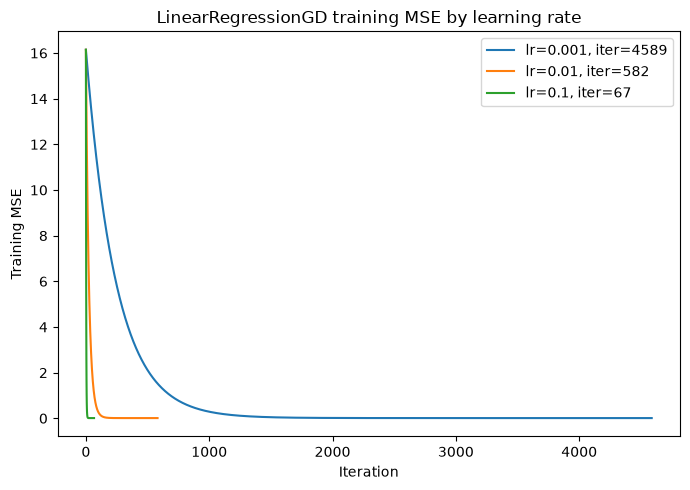

In [5]:
rng = np.random.default_rng(42)
N, p = 1000, 10
X = rng.normal(size=(N, p))
true_weights = rng.normal(size=p)
y = 2.0 + X @ true_weights + rng.normal(scale=0.1, size=N)

learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(7, 5))
for lr in learning_rates:
    model = LinearRegressionGD(lr=lr, max_iter=5000, tol=1e-6).fit(X, y)
    plt.plot(model.mse_history_, label=f"lr={lr}, iter={model.n_iter_}")

plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("LinearRegressionGD training MSE by learning rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part1_gd_mse.pdf", dpi=300)
plt.show()

**Polynomial fitting on California Housing dataset**

Best validation degree: 8


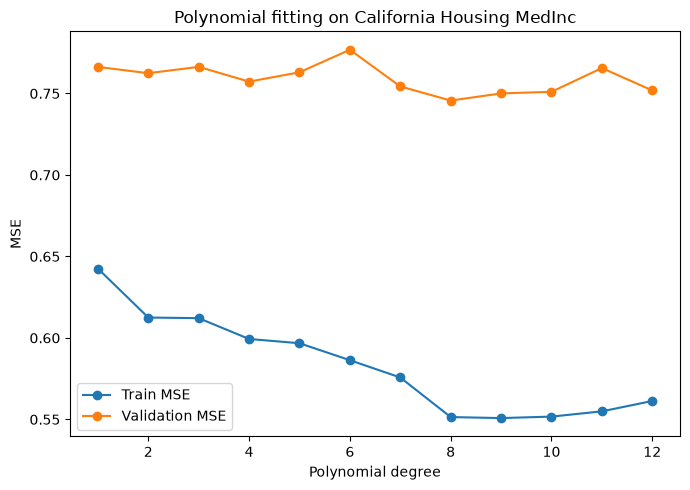

In [6]:
X_medinc = df_california.frame[["MedInc"]].to_numpy()
y_house = df_california.target

X_train, X_val, y_train, y_val = train_test_split(
    X_medinc, y_house, train_size=100, test_size=100, random_state=42
)

def polynomial_design(x, degree):
    x = np.asarray(x).reshape(-1)
    return np.column_stack([x ** d for d in range(1, degree + 1)])

train_mse = []
val_mse = []
degrees = range(1, 13)

for degree in degrees:
    Phi_train = polynomial_design(X_train, degree)
    Phi_val = polynomial_design(X_val, degree)

    mean = Phi_train.mean(axis=0)
    scale = Phi_train.std(axis=0)
    scale[scale == 0] = 1.0
    Phi_train_scaled = (Phi_train - mean) / scale
    Phi_val_scaled = (Phi_val - mean) / scale

    model = LinearRegression().fit(Phi_train_scaled, y_train)
    train_mse.append(sm.mean_squared_error(y_train, model.predict(Phi_train_scaled)))
    val_mse.append(sm.mean_squared_error(y_val, model.predict(Phi_val_scaled)))

best_degree = list(degrees)[int(np.argmin(val_mse))]
print("Best validation degree:", best_degree)

plt.figure(figsize=(7, 5))
plt.plot(list(degrees), train_mse, marker="o", label="Train MSE")
plt.plot(list(degrees), val_mse, marker="o", label="Validation MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Polynomial fitting on California Housing MedInc")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part1_polynomial_overfitting.pdf", dpi=300)
plt.show()

**Ridge and Lasso coefficients paths on Diabetes**

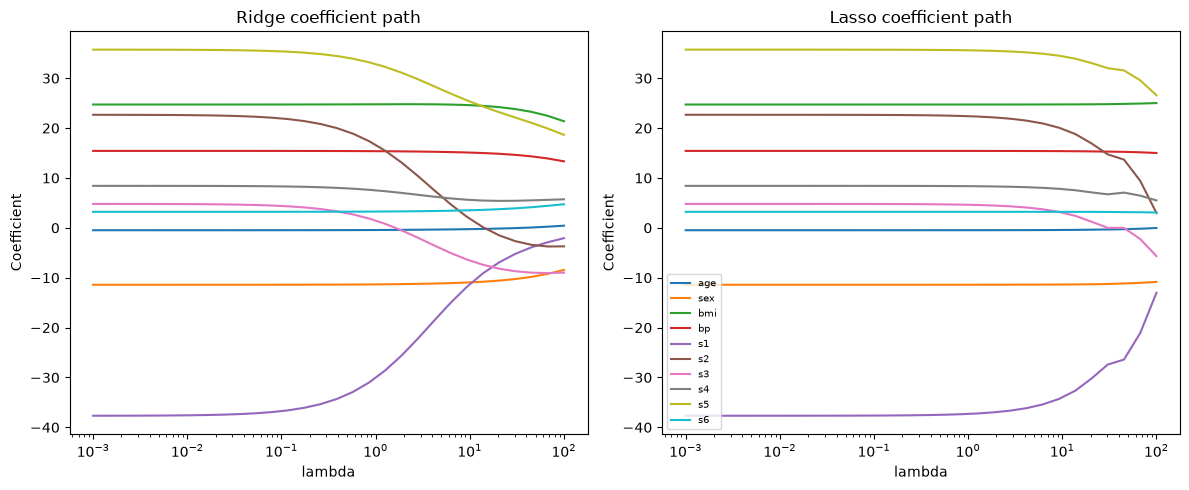

In [7]:
X_diabetes = df_diabetes.data.to_numpy()
y_diabetes = df_diabetes.target.to_numpy()

scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

lambdas = np.logspace(-3, 2, 30)
ridge_coefs = []
lasso_coefs = []

for lambda_ in lambdas:
    ridge = RidgeRegression(lambda_=lambda_).fit(X_diabetes_scaled, y_diabetes)
    lasso = LassoRegression(lambda_=lambda_, max_iter=10000, tol=1e-4).fit(X_diabetes_scaled, y_diabetes)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.vstack(ridge_coefs)
lasso_coefs = np.vstack(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for j, name in enumerate(df_diabetes.feature_names):
    axes[0].plot(lambdas, ridge_coefs[:, j], label=name)
    axes[1].plot(lambdas, lasso_coefs[:, j], label=name)

axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[0].set_xlabel("lambda")
axes[1].set_xlabel("lambda")
axes[0].set_ylabel("Coefficient")
axes[1].set_ylabel("Coefficient")
axes[0].set_title("Ridge coefficient path")
axes[1].set_title("Lasso coefficient path")
axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part2_diabetes_coefficient_paths.pdf", dpi=300)
plt.show()

Multiclass Logistic Regression vs Gaussian NB on Wine dataset

In [8]:
X_wine = df_wine.data.to_numpy()
y_wine = df_wine.target.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(lr=0.1, lambda_=0.01, max_iter=5000).fit(X_train_scaled, y_train)
nb_model = GaussianNaiveBayes().fit(X_train_scaled, y_train)

for name, model in [("Logistic Regression", lr_model), ("Gaussian NB", nb_model)]:
    pred = model.predict(X_test_scaled)
    print(name)
    print("accuracy:", sm.accuracy_score(y_test, pred))
    print("precision:", sm.precision_score(y_test, pred, average="macro"))
    print("recall:", sm.recall_score(y_test, pred, average="macro"))
    print("f1:", sm.f1_score(y_test, pred, average="macro"))
    print(sm.confusion_matrix(y_test, pred))
    print("-"*50)

Logistic Regression
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
--------------------------------------------------
Gaussian NB
accuracy: 0.9722222222222222
precision: 0.9743589743589745
recall: 0.9761904761904763
f1: 0.974320987654321
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]
--------------------------------------------------


**Text Classification Features**

In [9]:
bow = BagOfWords(max_features=5000).fit(df_news_train.data)

X_train_counts = bow.transform(df_news_train.data)
X_test_counts = bow.transform(df_news_test.data)

tfidf = TfidfTransformer().fit(X_train_counts)

X_train_tfidf = tfidf.transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

y_train = df_news_train.target
y_test = df_news_test.target

text_lr = LogisticRegression(
    lr=0.1,
    lambda_=0.01,
    max_iter=1000
).fit(X_train_tfidf, y_train)

text_nb = GaussianNaiveBayes().fit(X_train_tfidf, y_train)

results = {}

for name, model in [
    ("Logistic Regression", text_lr),
    ("Gaussian NB", text_nb)
]:
    pred = model.predict(X_test_tfidf)
    proba = model.predict_proba(X_test_tfidf)[:, 1]

    f1 = sm.f1_score(y_test, pred)
    auc = sm.roc_auc_score(y_test, proba)

    results[name] = {
        "f1": f1,
        "auc": auc,
        "proba": proba
    }

    print(name)
    print("F1:", round(f1, 4))
    print("AUC:", round(auc, 4))
    print()

Logistic Regression
F1: 0.9151
AUC: 0.9789

Gaussian NB
F1: 0.8936
AUC: 0.9152



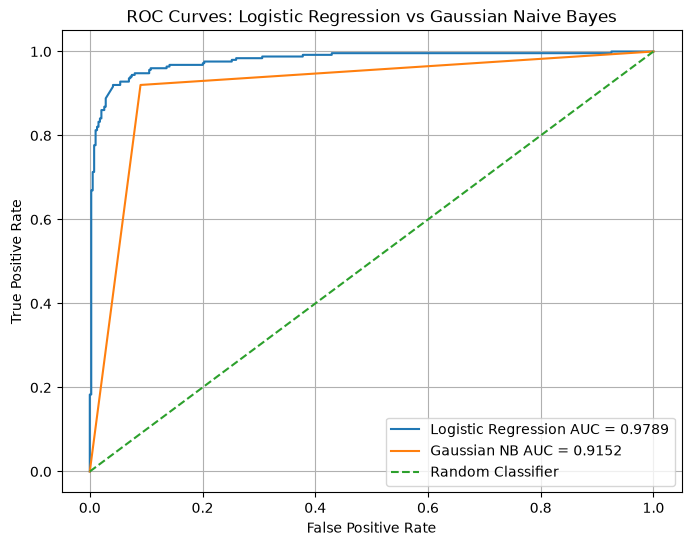

In [11]:
plt.figure(figsize=(8, 6))

for name, values in results.items():
    proba = values["proba"]
    auc = values["auc"]

    fpr, tpr, thresholds = sm.roc_curve(y_test, proba)

    plt.plot(fpr, tpr, label=f"{name} AUC = {auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Logistic Regression vs Gaussian Naive Bayes")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part3_text_roc.pdf", dpi=300)
plt.show()